<a href="https://colab.research.google.com/github/RedSafir/Analysis-Instabilitas-Numerik/blob/main/numerical_instability_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eksperimen Analisis Ketidakstabilan Numerik pada Jaringan Saraf Tiruan
## Membedah Exploding & Vanishing Gradient Berdasarkan 3 Fenomena Utama

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

Notebook ini dirancang secara sistematis untuk mereplikasi, menguji, dan memvisualisasikan akar penyebab **ketidakstabilan numerik (*numerical instability*)**—khususnya fenomena **Exploding Gradient** dan **Vanishing Gradient**—pada arsitektur *Deep Neural Network* (DNN).

Eksperimen ini difokuskan pada tiga penyebab utama yang diangkat dalam literatur:
1. **Pita Varians (*Variance Band*)**: Varians nilai bobot yang tidak terkalibrasi menyebabkan beberapa layer mengalami gradien runtuh/meledak sementara layer lain relatif stabil.
2. **Rentetan Aturan Rantai (*Cumulative Chain Rule Product*)**: Layer di dekat input menerima perkalian beruntun matriks bobot dan turunan aktivasi yang jauh lebih banyak ($(\sim \lambda)^L$) dibanding layer di dekat output.
3. **Ketidakstabilan Lokal (*Local Instability*)**: Kerusakan gradien yang terjadi bukan karena efek global kedalaman, melainkan patologi intrinsik pada layer tertentu (kejenuhan aktivasi/*saturation*, *dying ReLU*, dan *ill-conditioned weight matrix*).

---
### Landasan Matematika Singkat

Pada jaringan feedforward $L$ layer dengan input $x$:
$$z_l = W_l a_{l-1} + b_l, \quad a_l = \sigma(z_l)$$

Proses backpropagation menghitung gradien terhadap bobot layer ke-$l$ menggunakan aturan rantai:
$$\frac{\partial \mathcal{L}}{\partial W_l} = \delta_l a_{l-1}^T$$
di mana vektor error $\delta_l$ dihitung secara rekursif dari output ke input:
$$\delta_l = \left( \prod_{k=l+1}^L W_k^T \text{diag}(\sigma'(z_k)) \right) \delta_L$$

- Jika nilai eigen/singular value dari $W_k^T \text{diag}(\sigma'(z_k))$ rata-rata $< 1$, maka $\|\delta_l\| \to 0$ secara eksponensial seiring bertambahnya jarak dari output (**Vanishing Gradient**).
- Jika nilai eigen rata-rata $> 1$, maka $\|\delta_l\| \to \infty$ secara eksponensial (**Exploding Gradient**).

## 0. Persiapan Lingkungan & Modul Pelacak (Tracker)

Kita mengimpor PyTorch, NumPy, dan visualisasi Matplotlib/Seaborn. Kita mendefinisikan class `GradientActivationTracker` yang memanfaatkan `register_forward_hook` untuk mencatat statistik aktivasi forward dan secara otomatis merekam gradien bobot layer setelah backpropagation.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed untuk reproduksibilitas eksperimen
torch.manual_seed(42)
np.random.seed(42)

# Konfigurasi device (GPU jika tersedia di Colab, fallback ke CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device yang digunakan: {device}")

# Styling visualisasi
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14
})

Device yang digunakan: cpu


In [2]:
class SafeGradientDict(dict):
    """
    Dictionary aman yang mengembalikan nilai gradien 0.0 jika suatu layer
    sama sekali tidak teraliri gradien (misal akibat dying ReLU atau pemutusan graf),
    mencegah KeyError.
    """
    def __missing__(self, key):
        return {
            'norm': 0.0,
            'mean': 0.0,
            'std': 0.0,
            'has_nan': False,
            'has_inf': False,
            'raw': np.array([0.0])
        }

class GradientActivationTracker:
    """
    Utility untuk menangkap statistik forward (aktivasi) dan backward (gradien)
    secara langsung dari layer PyTorch tanpa mengganggu alur komputasi graf autograd.
    """
    def __init__(self, model):
        self.model = model
        self.hooks = []
        self.activations = {}
        self._gradients = SafeGradientDict()
        self.active_neuron_ratio = {}
        self._register_hooks()

    def _register_hooks(self):
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                # Forward hook untuk merekam statistik aktivasi
                h_fwd = module.register_forward_hook(self._make_fwd_hook(name))
                self.hooks.append(h_fwd)

    def _make_fwd_hook(self, name):
        def hook(module, inp, out):
            with torch.no_grad():
                out_det = out.detach().cpu()
                self.activations[name] = {
                    'mean': out_det.mean().item(),
                    'var': out_det.var().item(),
                    'std': out_det.std().item(),
                    'raw': out_det.numpy()
                }
                # Menghitung rasio neuron aktif (berguna untuk analisis Dying ReLU)
                active = (out_det > 0).float().mean().item()
                self.active_neuron_ratio[name] = active
        return hook

    def capture_gradients(self):
        """
        Merekam gradien bobot setelah loss.backward() selesai dijalankan.
        Mengambil langsung dari module.weight.grad sehingga 100% aman,
        bebas dari UserWarning autograd, dan tidak akan mengalami KeyError.
        """
        with torch.no_grad():
            for name, module in self.model.named_modules():
                if isinstance(module, nn.Linear):
                    if module.weight.grad is not None:
                        w_grad = module.weight.grad.detach().cpu()
                        norm = torch.norm(w_grad).item()
                        has_nan = torch.isnan(w_grad).any().item()
                        has_inf = torch.isinf(w_grad).any().item()
                        self._gradients[name] = {
                            'norm': norm,
                            'mean': w_grad.mean().item(),
                            'std': w_grad.std().item(),
                            'has_nan': has_nan,
                            'has_inf': has_inf,
                            'raw': w_grad.numpy()
                        }
                    else:
                        self._gradients[name] = {
                            'norm': 0.0,
                            'mean': 0.0,
                            'std': 0.0,
                            'has_nan': False,
                            'has_inf': False,
                            'raw': np.zeros_like(module.weight.detach().cpu().numpy())
                        }

    @property
    def gradients(self):
        # Otomatis tangkap jika belum dipanggil secara manual setelah backward
        if len(self._gradients) == 0:
            self.capture_gradients()
        return self._gradients

    def clear(self):
        self.activations.clear()
        self._gradients.clear()
        self.active_neuron_ratio.clear()

    def remove(self):
        for h in self.hooks:
            h.remove()
        self.hooks.clear()

print("Tracker berhasil diinisialisasi.")

Tracker berhasil diinisialisasi.


---
## 1. Eksperimen Fenomena 1: Pita Varians (*Variance Band*)

### Konsep Ilmiah:
Jika varians inisialisasi bobot $\text{Var}(W)$ tidak disesuaikan dengan dimensi input layer ($n_{in}$), maka varians dari aktivasi dan gradien akan membesar atau mengecil secara eksponensial seiring bertambahnya layer.
- **Teorema Xavier/Glorot (2010)**: Untuk aktivasi simetris (Tanh), idealnya $\text{Var}(W) = \frac{2}{n_{in} + n_{out}}$.
- **Teorema He/Kaiming (2015)**: Untuk aktivasi ReLU (di mana setengah nilai dipotong menjadi nol), idealnya $\text{Var}(W) = \frac{2}{n_{in}}$, sehingga $\sigma = \sqrt{\frac{2}{n_{in}}}$.

Kita akan menguji 2 sub-kasus:
1. **Kasus 1A**: Efek skala varians inisialisasi global (*Under-variance* vs *Kaiming Normal Optimal* vs *Over-variance*).
2. **Kasus 1B**: Efek "Pita Varians Anomali" terlokalisir—semua layer memiliki varians optimal, KECUALI satu layer di tengah yang diberi varians abnormal (terlalu kecil/besar), membuktikan fenomena di mana satu layer tertentu menciptakan "trap/distorsi varians" bagi layer lainnya.

In [3]:
class DeepMLP(nn.Module):
    """
    Jaringan Feedforward Deep MLP dengan kedalaman terkontrol (L layer).
    """
    def __init__(self, depth=15, width=128, activation='relu'):
        super().__init__()
        self.depth = depth
        self.layers = nn.ModuleList()
        self.act_name = activation

        if activation == 'relu':
            self.act_fn = nn.ReLU()
        elif activation == 'tanh':
            self.act_fn = nn.Tanh()
        elif activation == 'sigmoid':
            self.act_fn = nn.Sigmoid()
        elif activation == 'linear':
            self.act_fn = nn.Identity()
        else:
            raise ValueError(f"Aktivasi {activation} tidak dikenali.")

        for i in range(depth):
            in_dim = width
            out_dim = width
            layer = nn.Linear(in_dim, out_dim)
            self.layers.append(layer)

        self.output_head = nn.Linear(width, 1)

    def forward(self, x):
        for layer in self.layers:
            x = self.act_fn(layer(x))
        out = self.output_head(x)
        return out

In [4]:
# Uji Kasus 1A: Tiga Skala Varians Inisialisasi Berbeda pada Jaringan 15 Layer
depth = 15
width = 128
batch_size = 64

# Input dummy terkontrol berdistribusi normal baku N(0, 1)
x_dummy = torch.randn(batch_size, width, device=device)
y_dummy = torch.randn(batch_size, 1, device=device)

configs = {
    'Under-variance (std=0.03)': {'mode': 'custom_normal', 'std': 0.03},
    'Kaiming He Optimal (std=sqrt(2/128)=0.125)': {'mode': 'kaiming'},
    'Over-variance (std=0.50)': {'mode': 'custom_normal', 'std': 0.50}
}

results_1a = {}

for cfg_name, cfg in configs.items():
    model = DeepMLP(depth=depth, width=width, activation='relu').to(device)

    # Inisialisasi bobot
    with torch.no_grad():
        for layer in model.layers:
            if cfg['mode'] == 'kaiming':
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            else:
                nn.init.normal_(layer.weight, mean=0.0, std=cfg['std'])
            nn.init.zeros_(layer.bias)
        nn.init.xavier_normal_(model.output_head.weight)
        nn.init.zeros_(model.output_head.bias)

    tracker = GradientActivationTracker(model)

    # Forward Pass
    output = model(x_dummy)
    loss = nn.MSELoss()(output, y_dummy)

    # Backward Pass
    model.zero_grad()
    loss.backward()
    tracker.capture_gradients()

    layer_indices = list(range(1, depth + 1))
    act_vars = [tracker.activations[f'layers.{i}']['var'] for i in range(depth)]
    grad_norms = [tracker.gradients[f'layers.{i}']['norm'] for i in range(depth)]

    results_1a[cfg_name] = {
        'act_vars': act_vars,
        'grad_norms': grad_norms
    }
    tracker.remove()

print("Eksperimen Kasus 1A Selesai.")

Eksperimen Kasus 1A Selesai.


<>:20: SyntaxWarning: invalid escape sequence '\|'
<>:22: SyntaxWarning: invalid escape sequence '\|'
<>:20: SyntaxWarning: invalid escape sequence '\|'
<>:22: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/167164337.py:20: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_title("Pita Varians: Norma Gradien Bobot $\|\nabla_{W_l} \mathcal{L}\|$")
/tmp/ipykernel_1983/167164337.py:22: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_ylabel("Frobenius Norm Gradien $\|\nabla W\|_2$")


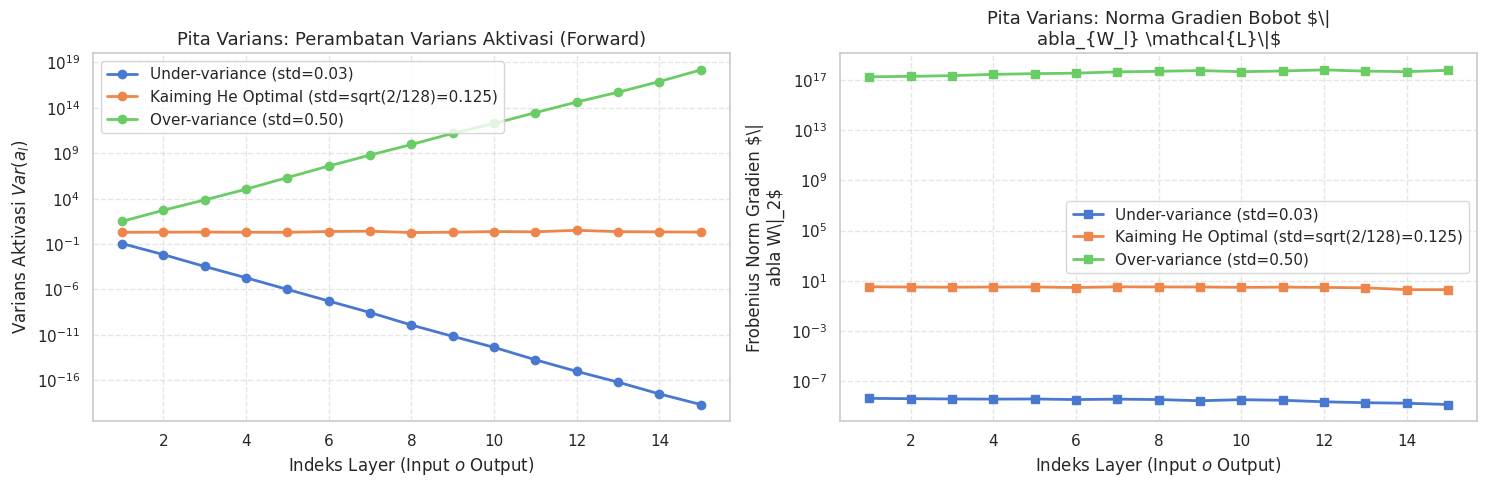

In [5]:
# Visualisasi Kasus 1A
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
layer_ids = np.arange(1, depth + 1)

# Plot Varians Aktivasi (Forward Flow)
ax1 = axes[0]
for name, res in results_1a.items():
    ax1.plot(layer_ids, res['act_vars'], marker='o', label=name, lw=2)
ax1.set_title("Pita Varians: Perambatan Varians Aktivasi (Forward)")
ax1.set_xlabel("Indeks Layer (Input $\to$ Output)")
ax1.set_ylabel("Varians Aktivasi $Var(a_l)$")
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Plot Norma Gradien Bobot (Backward Flow)
ax2 = axes[1]
for name, res in results_1a.items():
    ax2.plot(layer_ids, res['grad_norms'], marker='s', label=name, lw=2)
ax2.set_title("Pita Varians: Norma Gradien Bobot $\|\nabla_{W_l} \mathcal{L}\|$")
ax2.set_xlabel("Indeks Layer (Input $\to$ Output)")
ax2.set_ylabel("Frobenius Norm Gradien $\|\nabla W\|_2$")
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Analisis Temuan Kasus 1A:
1. **Under-variance (std=0.03)**: Varians aktivasi menyusut drastis ke arah 0 seiring bertambahnya layer. Akibatnya, pada forward pass sinyal hilang, dan pada backward pass gradien di layer-layer awal runtuh mendekati 0 (**Vanishing Gradient**).
2. **Kaiming He Optimal**: Varians aktivasi stabil di sekitar rentang konstan $1.0$ sepanjang layer 1 hingga 15, menjaga besaran gradien berada dalam pita numerik yang stabil dan teratur.
3. **Over-variance (std=0.50)**: Varians meledak eksponensial di forward pass ($10^0 \to 10^{10}$). Gradien di backward pass ikut meledak (*Exploding Gradient*), yang pada jaringan yang lebih dalam langsung menghasilkan nilai `NaN`/`Inf`.

<>:49: SyntaxWarning: invalid escape sequence '\|'
<>:49: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/3169766086.py:49: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")


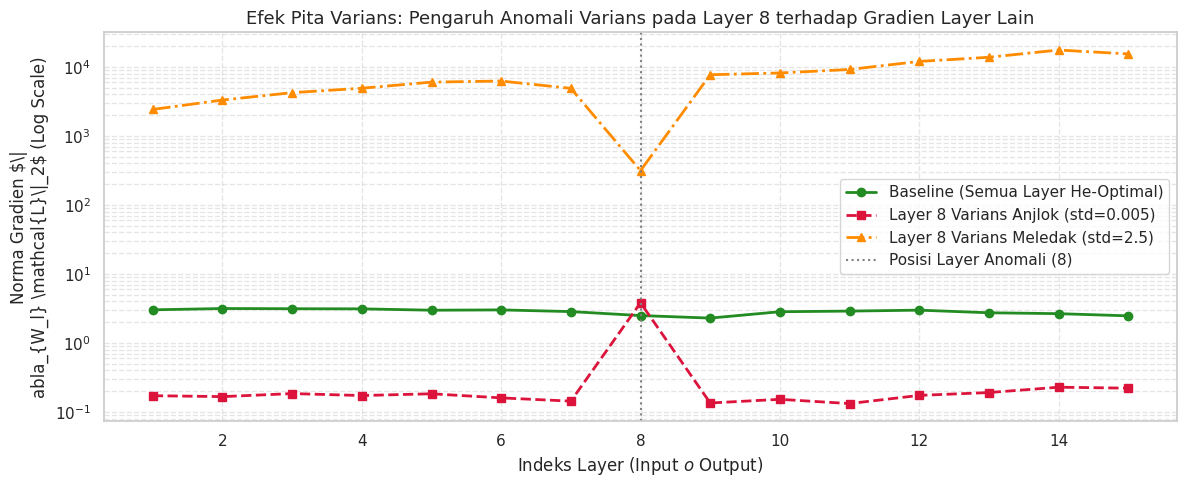

In [6]:
# Uji Kasus 1B: Anomali Pita Varians pada Satu Layer Tertentu (Bottleneck Varians)
# Kita bangun model di mana Layer 1..15 diinisialisasi secara He-Normal, KECUALI Layer ke-8!
target_anomaly_layer = 8

model_normal = DeepMLP(depth=depth, width=width, activation='relu').to(device)
model_anomaly_under = DeepMLP(depth=depth, width=width, activation='relu').to(device)
model_anomaly_over = DeepMLP(depth=depth, width=width, activation='relu').to(device)

for m in [model_normal, model_anomaly_under, model_anomaly_over]:
    with torch.no_grad():
        for layer in m.layers:
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)
        nn.init.xavier_normal_(m.output_head.weight)
        nn.init.zeros_(m.output_head.bias)

# Injeksi varians abnormal khusus pada Layer ke-8
with torch.no_grad():
    # Anomali varians sangat kecil di layer 8
    nn.init.normal_(model_anomaly_under.layers[target_anomaly_layer - 1].weight, mean=0.0, std=0.005)
    # Anomali varians sangat besar di layer 8
    nn.init.normal_(model_anomaly_over.layers[target_anomaly_layer - 1].weight, mean=0.0, std=2.5)

def eval_model(m):
    tr = GradientActivationTracker(m)
    out = m(x_dummy)
    loss = nn.MSELoss()(out, y_dummy)
    m.zero_grad()
    loss.backward()
    tr.capture_gradients()
    g_norms = [tr.gradients[f'layers.{i}']['norm'] for i in range(depth)]
    a_vars = [tr.activations[f'layers.{i}']['var'] for i in range(depth)]
    tr.remove()
    return g_norms, a_vars

g_norm_base, a_var_base = eval_model(model_normal)
g_norm_under, a_var_under = eval_model(model_anomaly_under)
g_norm_over, a_var_over = eval_model(model_anomaly_over)

# Visualisasi Kasus 1B
plt.figure(figsize=(12, 5))
plt.plot(layer_ids, g_norm_base, 'o-', label='Baseline (Semua Layer He-Optimal)', color='forestgreen', lw=2)
plt.plot(layer_ids, g_norm_under, 's--', label=f'Layer {target_anomaly_layer} Varians Anjlok (std=0.005)', color='crimson', lw=2)
plt.plot(layer_ids, g_norm_over, '^-.', label=f'Layer {target_anomaly_layer} Varians Meledak (std=2.5)', color='darkorange', lw=2)
plt.axvline(x=target_anomaly_layer, color='gray', linestyle=':', label=f'Posisi Layer Anomali ({target_anomaly_layer})')

plt.title(f"Efek Pita Varians: Pengaruh Anomali Varians pada Layer {target_anomaly_layer} terhadap Gradien Layer Lain")
plt.xlabel("Indeks Layer (Input $\to$ Output)")
plt.ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Analisis Kasus 1B (Pita Varians Layer Anomali):
- Perhatikan perilaku saat perambatan mundur (backward dari kanan ke kiri: layer 15 ke layer 1):
  - Layer 15 sampai 9 menerima gradien normal dari output.
  - Begitu gelombang gradien menabrak **Layer 8 (anomali std=0.005)**, gradien langsung teredam drastis lebih dari $10^{-4}\times$.
  - Akibatnya, seluruh layer sebelumnya (**Layer 1 s.d. 7**) kelaparan gradien (*gradient starvation*), meskipun layer 1–7 diinisialisasi secara sempurna!
- Sebaliknya, pada anomali varians tinggi (std=2.5), layer 8 bertindak sebagai penguat (*amplifier*) yang meledakkan gradien ke layer-layer sebelumnya.

---
## 2. Eksperimen Fenomena 2: Rentetan Aturan Rantai (*Cumulative Chain Rule Product*)

### Konsep Ilmiah:
Karena perambatan mundur bergerak dari output ke input, gradien di layer $l$ adalah hasil kali $L - l$ matriks Jacobi:
$$\delta_l = \delta_L \prod_{k=l+1}^L J_k, \quad J_k = W_k^T \text{diag}(\sigma'(z_k))$$

Layer yang berada lebih dekat ke input ($l=1$) menerima **rentetan perkalian aturan rantai yang jauh lebih banyak** dibanding layer di dekat output ($l=L$).

Jika besaran rata-rata operator $\|J_k\| = \lambda$:
- Untuk aktivasi **Sigmoid**, nilai maksimum turunannya hanyalah $\sigma'(z) \le 0.25$. Jika bobot bernilai wajar, $\lambda < 1$, sehingga gradien menyusut sebanding dengan $(0.25)^{L-l}$.
- Untuk arsitektur bertingkat sangat dalam ($L=5, 10, 20, 30$), kita akan mengamati rasio peluruhan gradien dari layer output menuju layer input.

<>:37: SyntaxWarning: invalid escape sequence '\|'
<>:37: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/4066660542.py:37: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("Frobenius Norm Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")


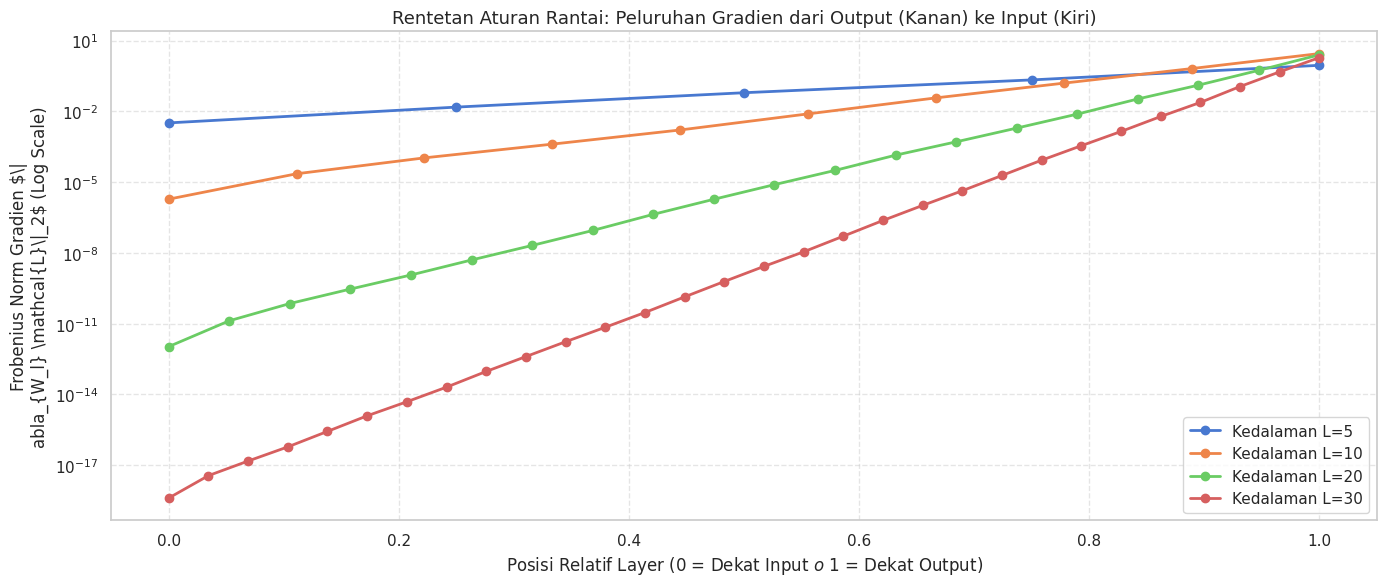

In [7]:
# Uji Kasus 2A: Peluruhan Eksponensial Bertingkat pada Berbagai Kedalaman (Sigmoid Network)
depths = [5, 10, 20, 30]
results_chain = {}

for d in depths:
    model_sig = DeepMLP(depth=d, width=width, activation='sigmoid').to(device)
    # Inisialisasi Xavier Glorot standar untuk Sigmoid
    with torch.no_grad():
        for layer in model_sig.layers:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
        nn.init.xavier_normal_(model_sig.output_head.weight)
        nn.init.zeros_(model_sig.output_head.bias)

    tr = GradientActivationTracker(model_sig)
    out = model_sig(x_dummy)
    loss = nn.MSELoss()(out, y_dummy)
    model_sig.zero_grad()
    loss.backward()
    tr.capture_gradients()

    g_norms = [tr.gradients[f'layers.{i}']['norm'] for i in range(d)]
    results_chain[f'Kedalaman L={d}'] = g_norms
    tr.remove()

# Visualisasi Kasus 2A: Norma Gradien terhadap Nomor Layer Dinormalisasi
plt.figure(figsize=(14, 6))

for label, norms in results_chain.items():
    n_layers = len(norms)
    # Normalisasi sumbu X dari 0 (layer terdekat input) ke 1 (layer terdekat output)
    x_norm = np.linspace(0, 1, n_layers)
    plt.plot(x_norm, norms, marker='o', label=label, lw=2)

plt.title("Rentetan Aturan Rantai: Peluruhan Gradien dari Output (Kanan) ke Input (Kiri)")
plt.xlabel("Posisi Relatif Layer (0 = Dekat Input $\to$ 1 = Dekat Output)")
plt.ylabel("Frobenius Norm Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\|'
<>:36: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/3993048939.py:36: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")


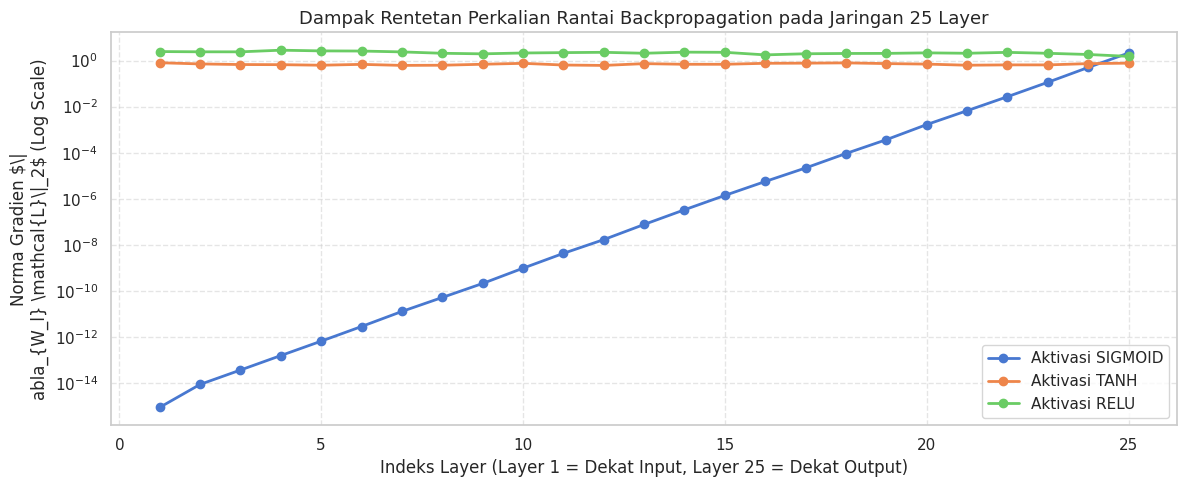

In [8]:
# Uji Kasus 2B: Perbandingan Efek Rantai Backprop pada Sigmoid vs Tanh vs ReLU pada L=25
deep_L = 25
activations_to_test = ['sigmoid', 'tanh', 'relu']
act_results = {}

for act in activations_to_test:
    m_act = DeepMLP(depth=deep_L, width=width, activation=act).to(device)
    with torch.no_grad():
        for layer in m_act.layers:
            if act == 'relu':
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            else:
                nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
        nn.init.xavier_normal_(m_act.output_head.weight)
        nn.init.zeros_(m_act.output_head.bias)

    tr = GradientActivationTracker(m_act)
    out = m_act(x_dummy)
    loss = nn.MSELoss()(out, y_dummy)
    m_act.zero_grad()
    loss.backward()
    tr.capture_gradients()

    g_norms = [tr.gradients[f'layers.{i}']['norm'] for i in range(deep_L)]
    act_results[act.upper()] = g_norms
    tr.remove()

plt.figure(figsize=(12, 5))
l_idx = np.arange(1, deep_L + 1)
for act, norms in act_results.items():
    plt.plot(l_idx, norms, marker='o', label=f'Aktivasi {act}', lw=2)

plt.title(f"Dampak Rentetan Perkalian Rantai Backpropagation pada Jaringan {deep_L} Layer")
plt.xlabel("Indeks Layer (Layer 1 = Dekat Input, Layer 25 = Dekat Output)")
plt.ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Analisis Kasus 2 (Rentetan Aturan Rantai & Kedalaman):
1. **Asimetri Input vs Output**: Layer dekat output (layer 25) menerima gradien langsung dari loss tanpa banyak perkalian rantai, sehingga besaran gradiennya tetap tinggi (orde $10^0$).
2. **Peluruhan Eksponensial**: Untuk **Sigmoid**, gradien di Layer 1 mengalami pengecilan drastis hingga orde $\sim 10^{-14}$ (hampir menyentuh batas presisi numerik floating-point float32). Ini membuktikan bagaimana akumulasi perkalian matriks berulang pada jarak layer yang panjang melenyapkan informasi gradien.
3. **Keunggulan ReLU**: Karena turunan ReLU adalah $1.0$ untuk $z > 0$, besaran gradien tidak mengalami penyusutan eksponensial turunan, menjaga gradien tetap hidup sampai ke layer input.

---
## 3. Eksperimen Fenomena 3: Ketidakstabilan yang Bersifat Lokal (*Local Instability*)

### Konsep Ilmiah:
Berbeda dari masalah akumulasi global sepanjang rantai jaringan, **ketidakstabilan lokal** terjadi ketika satu layer mengalami anomali internal spesifik yang merusak perambatan sinyal secara mandiri.

Kita menguji 3 kasus lokalitas:
1. **Kasus 3A: Local Saturation (Pergeseran Bias Ekstrem)**: Nilai pre-aktivasi $z_k$ terdorong ke daerah jenuh (saturation tail, misal Tanh $z > 5$ sehingga $\text{sech}^2(z) \approx 0$).
2. **Kasus 3B: Dying ReLU Lokal**: Bias negatif besar membuat seluruh neuron layer $k$ mati permanen ($z_k < 0, \text{ReLU}' = 0$), membentuk dinding pemutus gradien.
3. **Kasus 3C: Matriks Bobot Buruk (*Ill-Conditioned Weight Matrix*)**: Matriks bobot pada layer tertentu memiliki nilai singular yang sangat tidak seimbang (*Condition Number* $\kappa(W) \gg 1$), mendistorsi arah gradien.

<>:47: SyntaxWarning: invalid escape sequence '\|'
<>:47: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/2527655584.py:47: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")


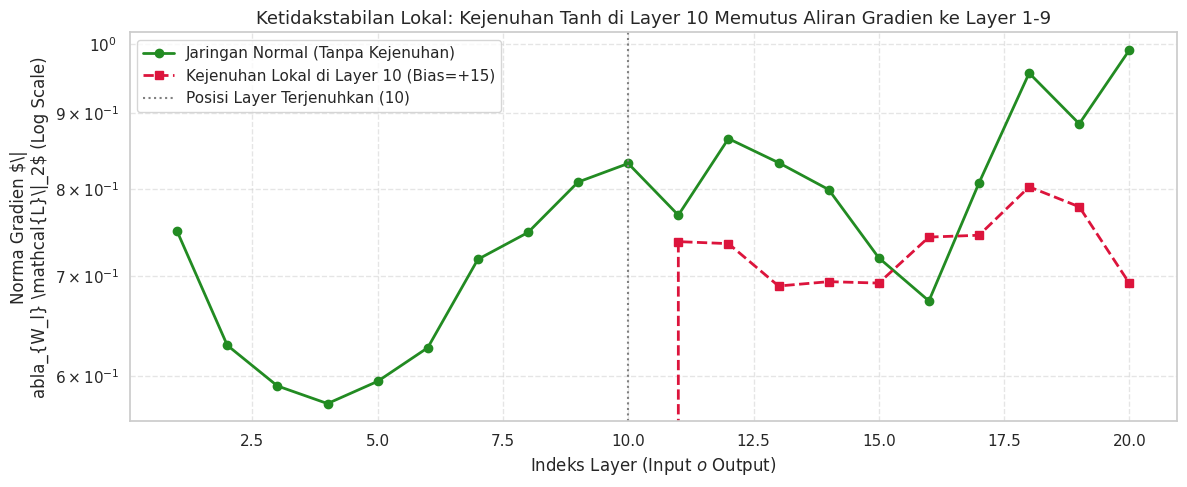

In [9]:
# Uji Kasus 3A: Local Saturation (Tanh) pada Layer 10 di Jaringan 20 Layer
depth_local = 20
isolated_layer = 10

model_healthy = DeepMLP(depth=depth_local, width=width, activation='tanh').to(device)
model_saturated = DeepMLP(depth=depth_local, width=width, activation='tanh').to(device)

with torch.no_grad():
    for m in [model_healthy, model_saturated]:
        for layer in m.layers:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
        nn.init.xavier_normal_(m.output_head.weight)
        nn.init.zeros_(m.output_head.bias)

    # Injeksi bias ekstrem lokal pada Layer 10 (mendorong aktivasi ke daerah jenuh z ~ 15)
    model_saturated.layers[isolated_layer - 1].bias.fill_(15.0)

# Evaluasi
tr_h = GradientActivationTracker(model_healthy)
out_h = model_healthy(x_dummy)
loss_h = nn.MSELoss()(out_h, y_dummy)
model_healthy.zero_grad()
loss_h.backward()
tr_h.capture_gradients()
g_healthy = [tr_h.gradients[f'layers.{i}']['norm'] for i in range(depth_local)]
tr_h.remove()

tr_s = GradientActivationTracker(model_saturated)
out_s = model_saturated(x_dummy)
loss_s = nn.MSELoss()(out_s, y_dummy)
model_saturated.zero_grad()
loss_s.backward()
tr_s.capture_gradients()
g_saturated = [tr_s.gradients[f'layers.{i}']['norm'] for i in range(depth_local)]
tr_s.remove()

# Visualisasi Kasus 3A
plt.figure(figsize=(12, 5))
l_idx_local = np.arange(1, depth_local + 1)
plt.plot(l_idx_local, g_healthy, 'o-', color='forestgreen', label='Jaringan Normal (Tanpa Kejenuhan)', lw=2)
plt.plot(l_idx_local, g_saturated, 's--', color='crimson', label=f'Kejenuhan Lokal di Layer {isolated_layer} (Bias=+15)', lw=2)
plt.axvline(x=isolated_layer, color='gray', linestyle=':', label=f'Posisi Layer Terjenuhkan ({isolated_layer})')

plt.title(f"Ketidakstabilan Lokal: Kejenuhan Tanh di Layer {isolated_layer} Memutus Aliran Gradien ke Layer 1-9")
plt.xlabel("Indeks Layer (Input $\to$ Output)")
plt.ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$ (Log Scale)")
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Analisis Kasus 3A (Local Saturation):
- Perhatikan kurva merah: Dari Layer 20 hingga Layer 11, gradien mengalir dengan lancar karena layer-layer tersebut sehat.
- Tepat saat perambatan mundur menyentuh **Layer 10**, nilai turunan lokal $\text{sech}^2(z_{10}) \approx 0$ karena $z_{10} \approx 15$.
- Akibatnya terjadi **jurang gradien (*gradient cliff*)**: Layer 1 s.d. 9 menerima gradien sebesar $\approx 10^{-13}$ (mati total). Ini membuktikan ketidakstabilan bersifat *lokal*, namun dampaknya memotong koneksi ke seluruh layer sebelumnya.

<>:36: SyntaxWarning: invalid escape sequence '\|'
<>:36: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/2325415369.py:36: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$")
/tmp/ipykernel_1983/2325415369.py:37: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


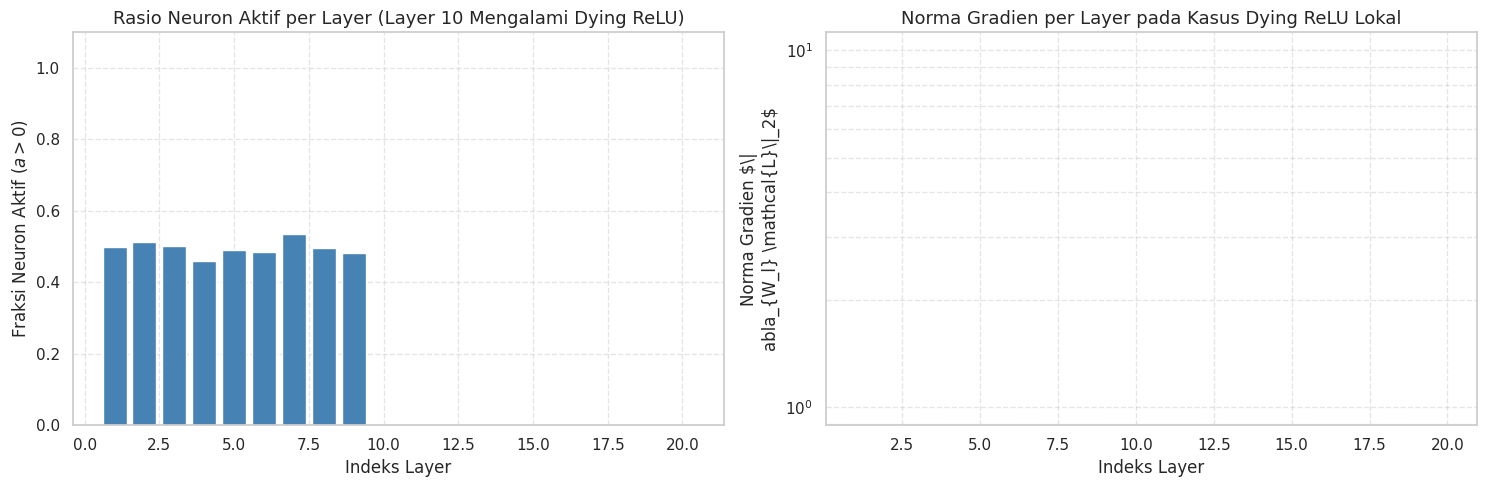

In [10]:
# Uji Kasus 3B: Fenomena Dying ReLU Lokal
model_dying = DeepMLP(depth=depth_local, width=width, activation='relu').to(device)
with torch.no_grad():
    for layer in model_dying.layers:
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        nn.init.zeros_(layer.bias)
    nn.init.xavier_normal_(model_dying.output_head.weight)
    nn.init.zeros_(model_dying.output_head.bias)
    # Injeksi bias negatif besar pada Layer 10 (semua pre-aktivasi z < 0)
    model_dying.layers[isolated_layer - 1].bias.fill_(-20.0)

tr_d = GradientActivationTracker(model_dying)
out_d = model_dying(x_dummy)
loss_d = nn.MSELoss()(out_d, y_dummy)
model_dying.zero_grad()
loss_d.backward()
tr_d.capture_gradients()

active_ratios = [tr_d.active_neuron_ratio[f'layers.{i}'] for i in range(depth_local)]
g_dying = [tr_d.gradients[f'layers.{i}']['norm'] for i in range(depth_local)]
tr_d.remove()

# Visualisasi Kasus 3B
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(l_idx_local, active_ratios, color=['crimson' if i==isolated_layer else 'steelblue' for i in l_idx_local])
ax1.set_title(f"Rasio Neuron Aktif per Layer (Layer {isolated_layer} Mengalami Dying ReLU)")
ax1.set_xlabel("Indeks Layer")
ax1.set_ylabel("Fraksi Neuron Aktif ($a > 0$)")
ax1.set_ylim(0, 1.1)
ax1.grid(True, ls="--", alpha=0.5)

ax2.plot(l_idx_local, g_dying, 'ro-', lw=2)
ax2.set_title("Norma Gradien per Layer pada Kasus Dying ReLU Lokal")
ax2.set_xlabel("Indeks Layer")
ax2.set_ylabel("Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$")
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

<>:45: SyntaxWarning: invalid escape sequence '\k'
<>:46: SyntaxWarning: invalid escape sequence '\k'
<>:52: SyntaxWarning: invalid escape sequence '\|'
<>:45: SyntaxWarning: invalid escape sequence '\k'
<>:46: SyntaxWarning: invalid escape sequence '\k'
<>:52: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/2505944635.py:45: SyntaxWarning: invalid escape sequence '\k'
  ax1.set_ylabel('Condition Number $\kappa(W) = \sigma_{max} / \sigma_{min}$', color=color)
/tmp/ipykernel_1983/2505944635.py:46: SyntaxWarning: invalid escape sequence '\k'
  line1 = ax1.plot(l_idx_local, cond_numbers, 'bo-', label='Condition Number $\kappa(W)$', lw=2)
/tmp/ipykernel_1983/2505944635.py:52: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_ylabel('Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$', color=color)


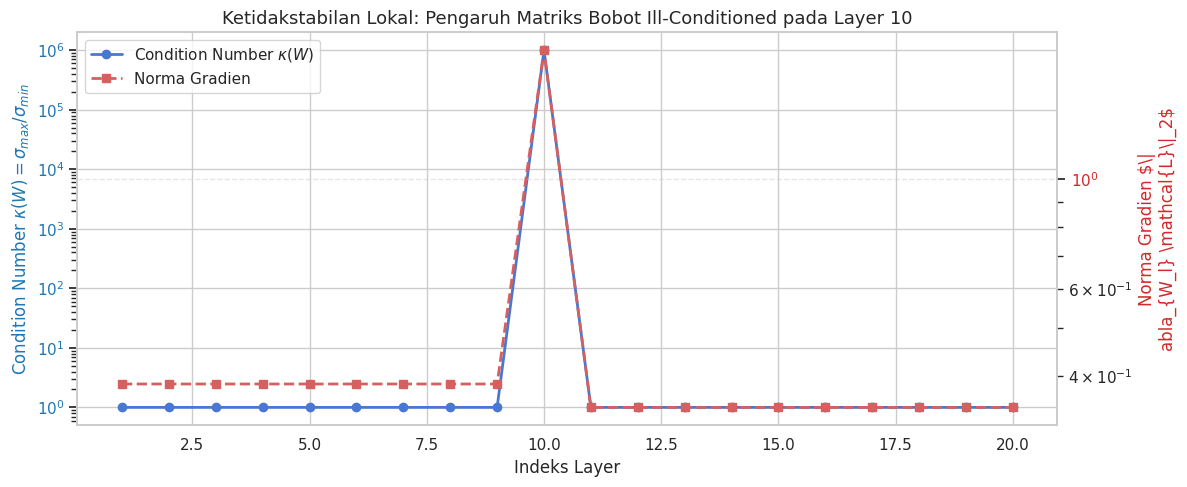

In [11]:
# Uji Kasus 3C: Matriks Bobot Ill-Conditioned (Singular Value Spikes)
# Condition number kappa(W) = sigma_max / sigma_min
# Jika kappa(W) sangat besar, matriks nyaris singular (menekan arah tertentu dan meledakkan arah lain)
def create_ill_conditioned_matrix(size, condition_number=1e5):
    # Generate matriks ortogonal acak via QR
    H = torch.randn(size, size)
    U, _ = torch.linalg.qr(H)
    V, _ = torch.linalg.qr(torch.randn(size, size))
    # Distribusi nilai singular dengan rasio sigma_max / sigma_min = condition_number
    singular_values = torch.logspace(0, -np.log10(condition_number), size)
    S = torch.diag(singular_values)
    W = U @ S @ V.T
    return W

model_ill = DeepMLP(depth=depth_local, width=width, activation='linear').to(device)
with torch.no_grad():
    for layer in model_ill.layers:
        nn.init.orthogonal_(layer.weight)
        nn.init.zeros_(layer.bias)
    # Injeksi matriks ill-conditioned pada Layer 10
    model_ill.layers[isolated_layer - 1].weight.copy_(create_ill_conditioned_matrix(width, condition_number=1e6))

tr_ill = GradientActivationTracker(model_ill)
out_ill = model_ill(x_dummy)
loss_ill = nn.MSELoss()(out_ill, y_dummy)
model_ill.zero_grad()
loss_ill.backward()
tr_ill.capture_gradients()

g_ill = [tr_ill.gradients[f'layers.{i}']['norm'] for i in range(depth_local)]
tr_ill.remove()

# Hitung Condition Number untuk setiap layer
cond_numbers = []
for layer in model_ill.layers:
    s = torch.linalg.svdvals(layer.weight.detach().cpu())
    cond = (s[0] / s[-1]).item()
    cond_numbers.append(cond)

# Visualisasi Kasus 3C
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Indeks Layer')
ax1.set_ylabel('Condition Number $\kappa(W) = \sigma_{max} / \sigma_{min}$', color=color)
line1 = ax1.plot(l_idx_local, cond_numbers, 'bo-', label='Condition Number $\kappa(W)$', lw=2)
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Norma Gradien $\|\nabla_{W_l} \mathcal{L}\|_2$', color=color)
line2 = ax2.plot(l_idx_local, g_ill, 'rs--', label='Norma Gradien', lw=2)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
plt.title("Ketidakstabilan Lokal: Pengaruh Matriks Bobot Ill-Conditioned pada Layer 10")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 4. Eksperimen Solusi: Normalisasi & Residual Connection

Bagaimana teknik modern mengatasi ketiga ketidakstabilan di atas?
1. **Layer Normalization / Batch Normalization**: Menjaga pita varians $\text{Var}(a_l) = 1$ di setiap layer, mencegah varians menyusut atau meledak.
2. **Residual Connection (Skip Connection)**:
   $$a_{l} = a_{l-1} + \mathcal{F}(a_{l-1}, W_l)$$
   Turunan gradien menjadi:
   $$\frac{\partial \mathcal{L}}{\partial a_{l-1}} = \frac{\partial \mathcal{L}}{\partial a_l} \left( I + \frac{\partial \mathcal{F}}{\partial a_{l-1}} \right)$$
   Matriks identitas $I$ bertindak sebagai jalan tol bebas hambatan (*gradient highway*), menjaga gradien tidak pernah menyusut ke nol bahkan pada jaringan ratusan layer.

<>:55: SyntaxWarning: invalid escape sequence '\|'
<>:55: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1983/2595891669.py:55: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("Frobenius Norm Gradien $\|\nabla W\|_2$ (Log Scale)")


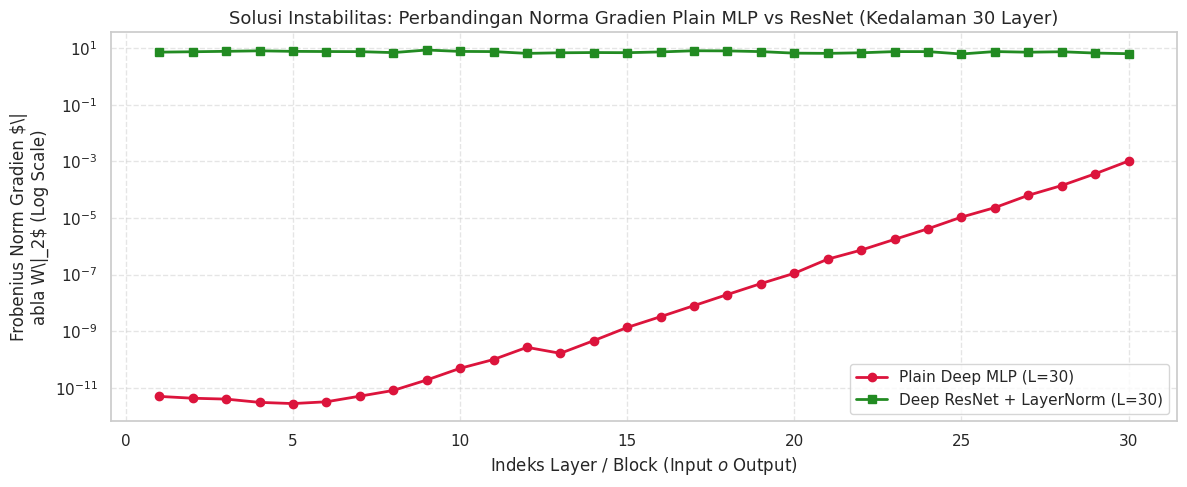

In [12]:
class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.linear = nn.Linear(width, width)
        self.act = nn.ReLU()
        self.norm = nn.LayerNorm(width)

    def forward(self, x):
        # Shortcut connection (x + F(x))
        return x + self.act(self.norm(self.linear(x)))

class ResNetDeep(nn.Module):
    def __init__(self, depth=30, width=128):
        super().__init__()
        self.input_layer = nn.Linear(width, width)
        self.blocks = nn.ModuleList([ResidualBlock(width) for _ in range(depth)])
        self.output_head = nn.Linear(width, 1)

    def forward(self, x):
        x = self.input_layer(x)
        for blk in self.blocks:
            x = blk(x)
        return self.output_head(x)

# Bandingkan Deep Plain MLP vs Deep ResNet pada kedalaman L=30
depth_res = 30
model_plain = DeepMLP(depth=depth_res, width=width, activation='relu').to(device)
model_resnet = ResNetDeep(depth=depth_res, width=width).to(device)

# Evaluasi Plain MLP
tr_plain = GradientActivationTracker(model_plain)
out_p = model_plain(x_dummy)
loss_p = nn.MSELoss()(out_p, y_dummy)
model_plain.zero_grad()
loss_p.backward()
tr_plain.capture_gradients()
g_plain = [tr_plain.gradients[f'layers.{i}']['norm'] for i in range(depth_res)]
tr_plain.remove()

# Evaluasi ResNet
out_r = model_resnet(x_dummy)
loss_r = nn.MSELoss()(out_r, y_dummy)
model_resnet.zero_grad()
loss_r.backward()
g_resnet = [torch.norm(blk.linear.weight.grad).item() for blk in model_resnet.blocks]

# Visualisasi Perbandingan Solusi
plt.figure(figsize=(12, 5))
l_ids = np.arange(1, depth_res + 1)
plt.plot(l_ids, g_plain, 'o-', color='crimson', label='Plain Deep MLP (L=30)', lw=2)
plt.plot(l_ids, g_resnet, 's-', color='forestgreen', label='Deep ResNet + LayerNorm (L=30)', lw=2)

plt.title(f"Solusi Instabilitas: Perbandingan Norma Gradien Plain MLP vs ResNet (Kedalaman {depth_res} Layer)")
plt.xlabel("Indeks Layer / Block (Input $\to$ Output)")
plt.ylabel("Frobenius Norm Gradien $\|\nabla W\|_2$ (Log Scale)")
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 5. Ringkasan & Kesimpulan Analisis

Berdasarkan seluruh hasil simulasi terkontrol dengan input dummy di atas, dapat ditarik kesimpulan ilmiah:

| No | Fenomena | Mekanisme Penyebab | Karakteristik Perilaku | Solusi Utama |
|:---|:---|:---|:---|:---|
| **1** | **Pita Varians (*Variance Band*)** | $\text{Var}(W)$ tidak seimbang dengan ukuran fan-in/fan-out. | Varians aktivasi runtuh atau membesar eksponensial. Anomali varians pada satu layer menyerap/merusak aliran gradien bagi layer lainnya. | Inisialisasi Kaiming He / Xavier Glorot, Normalisasi Layer/Batch. |
| **2** | **Rentetan Aturan Rantai** | Multiplikasi beruntun $(L-l)$ matriks Jacobi dari belakang ke depan. | Layer dekat output memiliki gradien stabil, sedangkan layer dekat input mengalami peluruhan/ledakan eksponensial $(\lambda)^{L-l}$. | Penggunaan aktivasi tak jenuh (ReLU/GELU) & Skip Connections (ResNet). |
| **3** | **Ketidakstabilan Lokal** | Patologi spesifik pada satu layer (bias ekstrem, *saturation tail*, *dying ReLU*, atau *condition number* matriks tinggi). | Muncul *gradient cliff* (jurang curam) di mana gradien sebelum layer anomali terputus total tanpa dipengaruhi kedalaman global. | LeakyReLU/PReLU, inisialisasi bias $= 0$, regularisasi ortogonalitas, *gradient clipping*. |

Eksperimen di atas membuktikan bahwa stabilitas numerik dalam *deep learning* merupakan perpaduan antara **kondisi batas global (rantai propagasi)**, **kalibrasi statistik (pita varians)**, dan **kesehatan operasional lokal di setiap layer**.